In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [42]:
rfm = pd.read_csv('rfm.csv', index_col='customerid')

In [43]:
rfm.sample(10)

,Recency,Frequency,Monetary,R_log,F_log,M_log,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Customer_Segment
customerid,,,,,,,,,,,,
13928.0,11,4,464.57,2.484907,1.609438,6.143262,5,4,3,543,12,Loyal Customers
15787.0,26,3,933.26,3.295837,1.386294,6.839755,4,3,4,434,11,Others
13014.0,11,10,3466.28,2.484907,2.397895,8.151126,5,5,5,555,15,Champions
15830.0,38,1,576.00,3.663562,0.693147,6.357842,3,1,3,313,7,Others
17266.0,2,3,296.58,1.098612,1.386294,5.695683,5,4,2,542,11,Loyal Customers
16106.0,66,1,108.38,4.204693,0.693147,4.694828,3,2,1,321,6,Others
14036.0,285,1,626.65,5.655992,0.693147,6.441983,1,1,3,113,5,Lost
13193.0,61,1,112.08,4.127134,0.693147,4.728096,3,1,1,311,5,Others
13146.0,26,1,228.91,3.295837,0.693147,5.437688,4,1,1,411,6,Potential Loyalists


In [44]:
rfm.isnull().sum()

Recency             0
Frequency           0
Monetary            0
R_log               0
F_log               0
M_log               0
R_Score             0
F_Score             0
M_Score             0
RFM_Segment         0
RFM_Score           0
Customer_Segment    0
dtype: int64

In [45]:
rfm.shape

(3917, 12)

In [46]:
rfm.dtypes

Recency               int64
Frequency             int64
Monetary            float64
R_log               float64
F_log               float64
M_log               float64
R_Score               int64
F_Score               int64
M_Score               int64
RFM_Segment           int64
RFM_Score             int64
Customer_Segment     object
dtype: object

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])

In [48]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print(" Calculating Inertia & Silhouette Scores ")
# Create empty lists to store our metrics
inertia = []
silhouette_scores = []

# Define the range of k (number of clusters) we want to test
K_range = range(2, 11)

for k in K_range:
    # Initialize K-Means (random_state ensures your results are reproducible)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Fit the model and assign labels
    cluster_labels = kmeans.fit_predict(rfm_scaled)
    
    # Store the Inertia (Sum of Squared Distances)
    inertia.append(kmeans.inertia_)
    
    # Store the Silhouette Score
    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)
    
    print(f"Tested k={k} | Inertia: {kmeans.inertia_:,.0f} | Silhouette Score: {score:.4f}")

 Calculating Inertia & Silhouette Scores 
Tested k=2 | Inertia: 5,806 | Silhouette Score: 0.4352
Tested k=3 | Inertia: 4,333 | Silhouette Score: 0.3416
Tested k=4 | Inertia: 3,500 | Silhouette Score: 0.3394
Tested k=5 | Inertia: 2,927 | Silhouette Score: 0.3187
Tested k=6 | Inertia: 2,530 | Silhouette Score: 0.3157
Tested k=7 | Inertia: 2,254 | Silhouette Score: 0.3115
Tested k=8 | Inertia: 2,063 | Silhouette Score: 0.3062
Tested k=9 | Inertia: 1,897 | Silhouette Score: 0.2842
Tested k=10 | Inertia: 1,758 | Silhouette Score: 0.2817


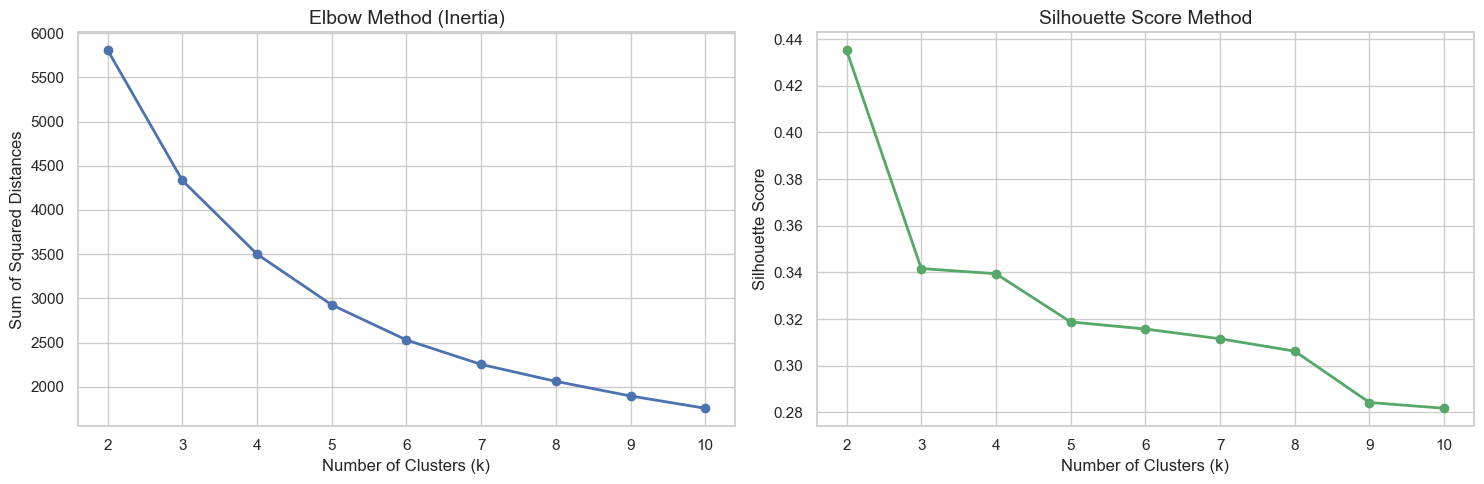

In [50]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The Elbow Method (Inertia)
axes[0].plot(K_range, inertia, marker='o', color='b', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Sum of Squared Distances', fontsize=12)
axes[0].set_xticks(K_range)

# Plot 2: The Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='o', color='g', linewidth=2)
axes[1].set_title('Silhouette Score Method', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig('kmeans_optimal_k_evaluation.png', dpi=300)

In [51]:
print("\n--- 1. Assigning Customers to Clusters ---")
optimal_k = 4

# Initialize and fit the model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"Successfully assigned {len(rfm):,} customers into {optimal_k} clusters.")


--- 1. Assigning Customers to Clusters ---
Successfully assigned 3,917 customers into 4 clusters.


In [52]:
joblib.dump(kmeans_final, 'segmentation_model.pkl')

['segmentation_model.pkl']

In [53]:
print("\n--- 2. Cluster Profiling ---")
# We use the original Recency, Frequency, and Monetary columns (NOT the logs/scaled ones)
# so the numbers actually make sense to stakeholders in dollars and days.

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Flatten the multi-level column names for cleaner printing
cluster_profile.columns = ['Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary_Spend', 'Customer_Count']

# Sort by Monetary spend to see the most valuable clusters at the top
cluster_profile = cluster_profile.sort_values(by='Avg_Monetary_Spend', ascending=False)

print(cluster_profile)


--- 2. Cluster Profiling ---
         Avg_Recency_Days  Avg_Frequency  Avg_Monetary_Spend  Customer_Count
Cluster                                                                     
1                    11.5           13.7              7203.3             630
0                    68.3            4.2              1727.0            1055
2                    19.2            2.1               519.2             771
3                   183.2            1.3               330.9            1461



--- 3. Generating Cluster Boxplots ---


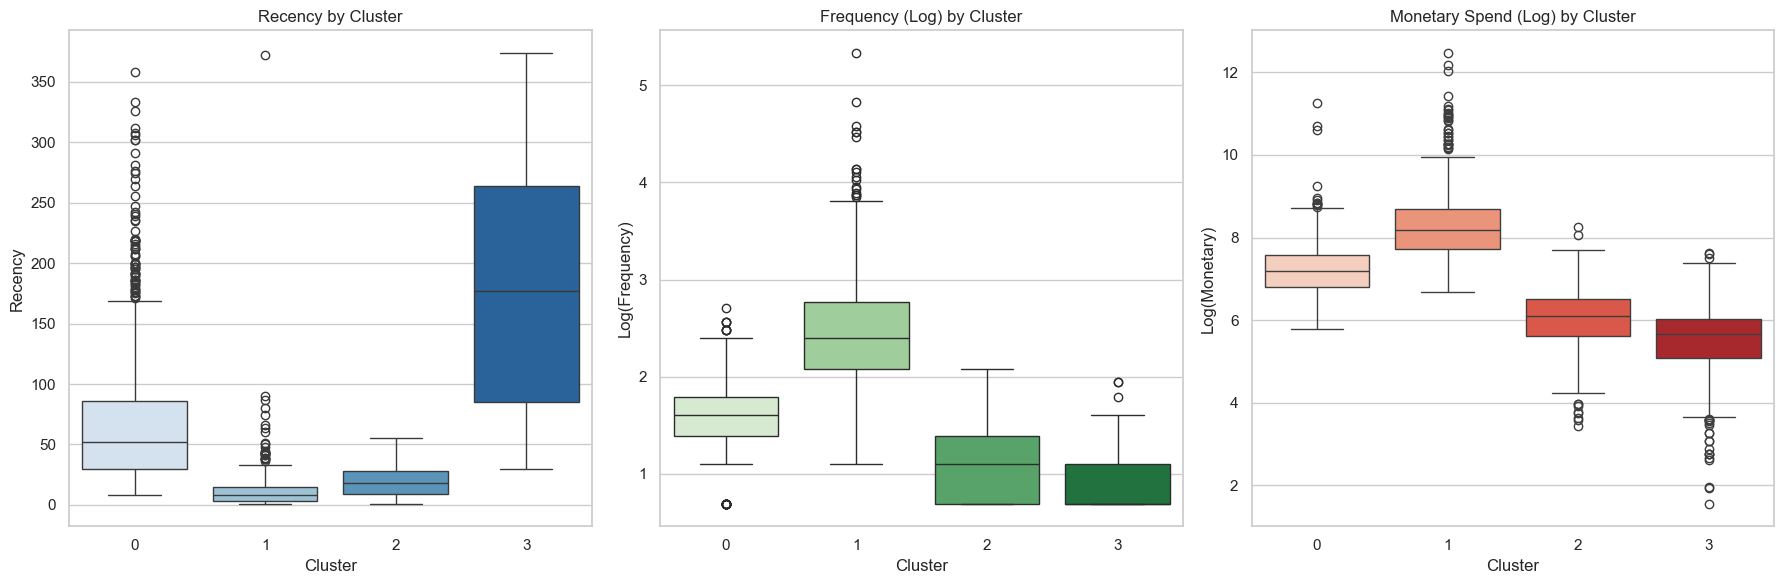

In [54]:
print("\n--- 3. Generating Cluster Boxplots ---")
# Boxplots are fantastic for showing how different the groups are
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# Recency Boxplot
sns.boxplot(x='Cluster', y='Recency', data=rfm, ax=axes[0], palette='Blues')
axes[0].set_title('Recency by Cluster')

# Frequency Boxplot (using Log so extreme outliers don't crush the visual)
sns.boxplot(x='Cluster', y='F_log', data=rfm, ax=axes[1], palette='Greens')
axes[1].set_title('Frequency (Log) by Cluster')
axes[1].set_ylabel('Log(Frequency)')

# Monetary Boxplot (using Log)
sns.boxplot(x='Cluster', y='M_log', data=rfm, ax=axes[2], palette='Reds')
axes[2].set_title('Monetary Spend (Log) by Cluster')
axes[2].set_ylabel('Log(Monetary)')

plt.tight_layout()
plt.savefig('kmeans_cluster_profiles.png', dpi=300)

In [55]:
cluster_map = {1: "Champions", 0: "Loyal Base", 2: "Potential Loyals", 3: 'Lost/Inactive'}

rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_map)

In [56]:
rfm[['Customer_Segment', 'Cluster_Label']]

,Customer_Segment,Cluster_Label
customerid,,
12346.0,Lost,Loyal Base
12747.0,Champions,Champions
12748.0,Champions,Champions
12749.0,Loyal Customers,Champions
12820.0,Loyal Customers,Potential Loyals
...,...,...
18280.0,Others,Lost/Inactive
18281.0,Others,Lost/Inactive
18282.0,Others,Potential Loyals


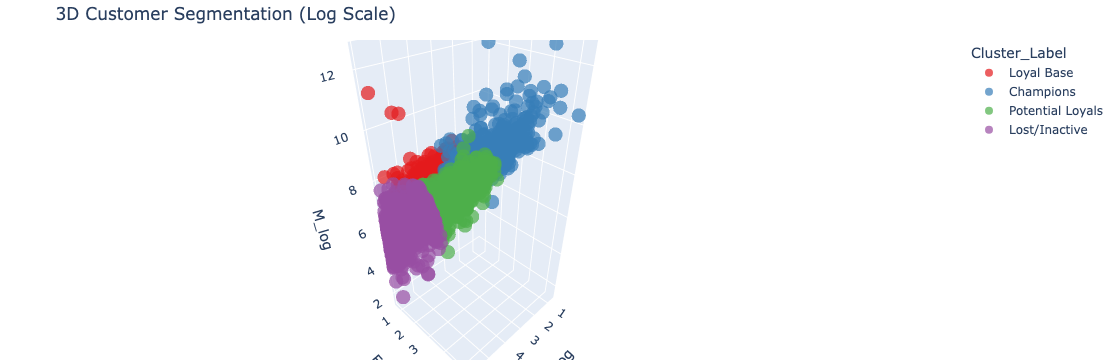

Saved 3D plot as 'rfm_3d_clusters.html'


In [57]:
import plotly.express as px

fig_3d = px.scatter_3d(
    rfm, 
    x='R_log', 
    y='F_log', 
    z='M_log',
    color='Cluster_Label',
    hover_name='Cluster_Label',
    hover_data={'Recency': True, 'Frequency': True, 'Monetary': True, 'R_log': False, 'F_log': False, 'M_log': False},
    title='3D Customer Segmentation (Log Scale)',
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.7
)

# Update layout for a cleaner look
fig_3d.update_layout(margin=dict(l=0, r=0, b=0, t=40))

# To view this in a Jupyter Notebook, simply call:
fig_3d.show()

# To save it as an interactive HTML file you can open in your browser:
fig_3d.write_html("rfm_3d_clusters.html")
print("Saved 3D plot as 'rfm_3d_clusters.html'")

Saved Averages Bar Chart as 'cluster_averages_barchart.png'


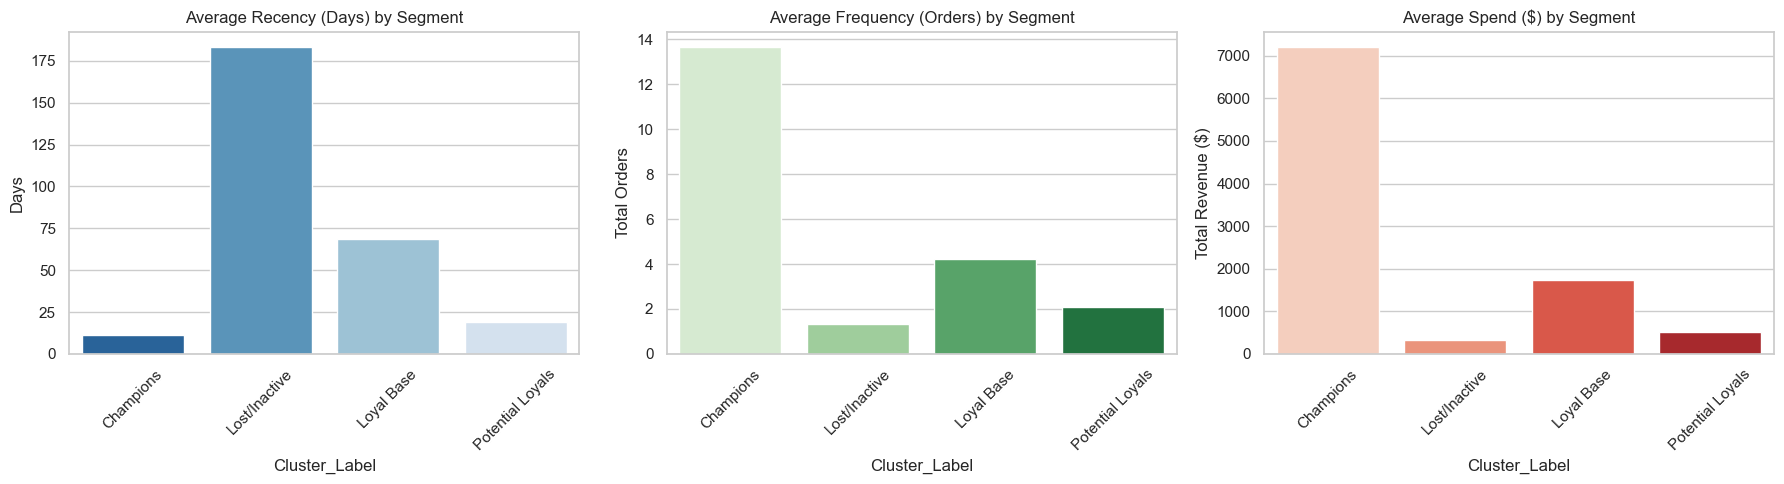

In [58]:
cluster_avg = rfm.groupby('Cluster_Label')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Recency
sns.barplot(x='Cluster_Label', y='Recency', data=cluster_avg, ax=axes[0], palette='Blues_r')
axes[0].set_title('Average Recency (Days) by Segment')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=45)

# Average Frequency
sns.barplot(x='Cluster_Label', y='Frequency', data=cluster_avg, ax=axes[1], palette='Greens')
axes[1].set_title('Average Frequency (Orders) by Segment')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x', rotation=45)

# Average Monetary
sns.barplot(x='Cluster_Label', y='Monetary', data=cluster_avg, ax=axes[2], palette='Reds')
axes[2].set_title('Average Spend ($) by Segment')
axes[2].set_ylabel('Total Revenue ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cluster_averages_barchart.png', dpi=300)
print("Saved Averages Bar Chart as 'cluster_averages_barchart.png'")

Saved Cluster Size Distribution as 'cluster_size_distribution.png'


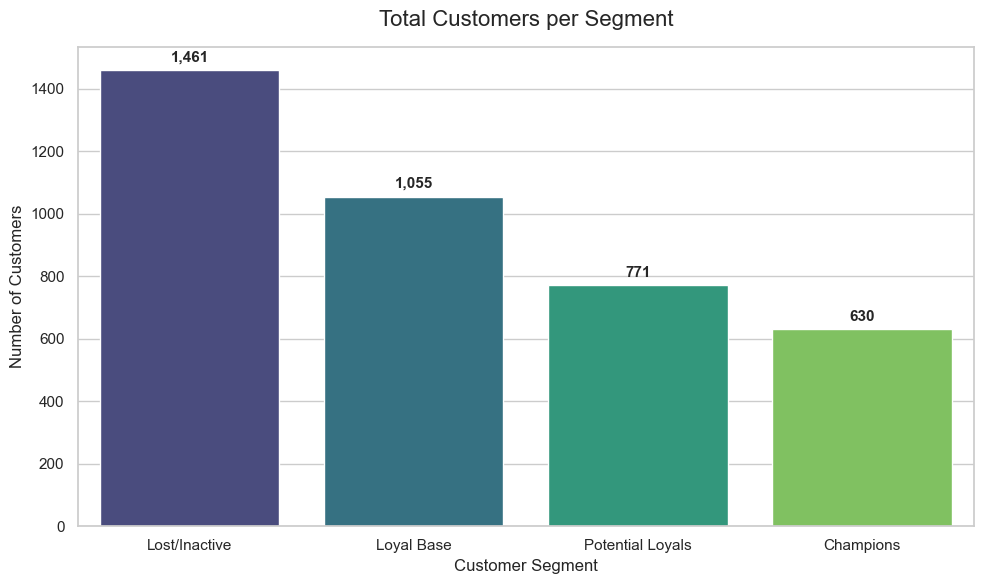

In [59]:
plt.figure(figsize=(10, 6))

# Count the number of users per cluster and sort them for a cleaner chart
cluster_counts = rfm['Cluster_Label'].value_counts().reset_index()
cluster_counts.columns = ['Segment', 'Customer Count']

ax = sns.barplot(x='Segment', y='Customer Count', data=cluster_counts, palette='viridis')

plt.title('Total Customers per Segment', fontsize=16, pad=15)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add the exact numbers on top of the bars for easy reading in a presentation
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_size_distribution.png', dpi=300)
print("Saved Cluster Size Distribution as 'cluster_size_distribution.png'")

In [60]:
rfm.reset_index().to_csv('rfm_segmented.csv', index=False)